In [2]:
import numpy as np

from numba import njit, prange, get_num_threads, threading_layer, set_num_threads, config

import subprocess

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.mlab as mlab
import json
import pandas as pd


from scipy.stats import chi2, poisson
from scipy.integrate import quad
from scipy.optimize import brute, minimize
from scipy.fft import rfft, rfftfreq
from scipy import signal
#from gatspy.periodic import LombScargleFast

In [ ]:
# Produced by Google AI, not verified
# import numpy as np
# import scipy.stats as stats

# def simulate_inhomogeneous_poisson_process(lambda_t, T):
#   """Simulates an inhomogeneous Poisson process with intensity function lambda_t over the interval [0, T].

#   Args:
#     lambda_t: A function that takes a time t and returns the intensity of the process at that time.
#     T: The end time of the simulation.

#   Returns:
#     A list of the times at which events occur in the process.
#   """

#   # Simulate a homogeneous Poisson process with an upper bound intensity value.
#   lambda_max = np.max(lambda_t(np.arange(T)))
#   homogeneous_events = stats.poisson(lambda_max * T).rvs()

#   # Thin the homogeneous Poisson process with a thinning probability function.
#   thinning_probabilities = lambda_t(homogeneous_events) / lambda_max
#   inhomogeneous_events = []
#   for i, event in enumerate(homogeneous_events):
#     if np.random.random() < thinning_probabilities[i]:
#       inhomogeneous_events.append(event)

#   return inhomogeneous_events

# # Example usage:

# lambda_t = lambda t: 2 * t
# T = 10

# events = simulate_inhomogeneous_poisson_process(lambda_t, T)

# print(events)

In [3]:
def inhomogeneous_poisson_process(f, T, rate=1):
    '''
    f : rate function (should be non-negative; 
        will be normalized to probabilities)
    T : time span
    rate : N_total / T
    
    returns sorted np array of event times 
    in interval [0, T)
    '''
    
    n = np.random.poisson(rate * T) # number of events
    
    norm = quad(f, 0, T)[0]
        
    events = []
    while len(events) < n:
        t = np.random.rand() * T
        if np.random.rand() < f(t) / norm:
            events.append(t)
            
    return np.sort(events)     

In [4]:
rate_func = lambda p, f: lambda t: 1 + p*np.cos(2 * np.pi * (f+0.0001*t) * t)   

In [5]:
n_threads = config.NUMBA_NUM_THREADS
set_num_threads(n_threads)

In [6]:

# YOU SHOULD WRITE YOUR OWN Rayleigh test rather than trying to understand these complex functions where some speed optimization is used. 
# Direct Z_n^2 computation; Zs array contains Z_n^2 values for n=1 to n=nharm
@njit(parallel=True)
def Z1_numba_cpu(data, f, fdot):
    
    arg = 2 * np.pi * data * (f + fdot * data / 2)
    sum_cos = np.sum(np.cos(arg))
    sum_sin = np.sum(np.sin(arg))
    
    return 2 * (sum_cos**2 + sum_sin**2) / len(data)

def Znsq_grid(freqs, fdots, ts, nharm=1):
    
    Zs = np.array([[[Z1_numba_cpu(ts, k * f, k * fdot) 
                           for f in freqs] 
                          for fdot in fdots] 
                         for k in np.arange(1, nharm+1)])
        
    Zs = np.cumsum(Zs, axis=0)    
    
    #return freqs, fdots, Zs
    
    if Zs.shape==(1,1):
        return Zs[0,0].T  
    
    if Zs.shape[0]==1:
        return Zs[0].T 
    
    if Zs.shape[1]==1:
        return Zs[:,0].T 
    
    return  Zs[-1].T

In [7]:
# YOU SHOULD WRITE YOUR OWN Rayleigh test rather than trying to understand these complex functions where some speed optimization is used. 


# Optimized Z_n^2 computation; z2s array contains Z_n^2 values for only n=nharm


@njit(fastmath=True, parallel=True)
def Z2_f_fdot(f, fdot, ts):
    
    args = 2 * np.pi * ts * (f + fdot * ts / 2)

    sn = np.sum(np.cos(args))
    cs = np.sum(np.sin(args))
    
    return 2 * (sn**2 + cs**2) / len(ts)

@njit(fastmath=True, parallel=True)
def Z2_f_fdots_exact(f, fdots, ts, steps=100_000):
    
    out = np.empty_like(fdots)
    
    for i in prange(len(fdots)):
        fdot = fdots[i]
        args = 2 * np.pi * ts * (f + fdot * ts / 2)
        sn = np.sum(np.sin(args)) 
        cs = np.sum(np.cos(args))
        out[i] = sn * sn + cs * cs
            
    return out * 2 / len(ts)

@njit(fastmath=True, parallel=True)
def Z2_fs_fdot_exact(fs, fdot, ts, steps=100_000):
    
    out = np.empty_like(fs)
    
    for i in prange(len(fs)):
        f = fs[i]
        args = 2 * np.pi * ts * (f + fdot * ts / 2)
        sn = np.sum(np.sin(args)) 
        cs = np.sum(np.cos(args))
        out[i] = sn * sn + cs * cs
            
    return out * 2 / len(ts)

@njit(fastmath=True, parallel=True)
def Z2_f_fdots_boost(f, fdots, ts, steps=100_000):
    
    out = np.empty_like(fdots)
    
    dfdot = fdots[1] - fdots[0]
        
    darg = np.pi * dfdot * ts**2
    
    dc = np.cos(darg)
    ds = np.sin(darg)
    
    dz = dc + 1j*ds
    
    arg = 2 * np.pi * ts * (f + fdots[0] * ts / 2)

    c = np.cos(arg)
    s = np.sin(arg)

    z = c + 1j*s
                
    for i in range(len(fdots)):
        
        if np.mod(i+1, steps) == 0:
            
            arg = 2 * np.pi * ts * (f + fdots[i] * ts / 2)
    
            c = np.cos(arg)
            s = np.sin(arg)

            z = c + 1j*s
        
        z_sum = np.sum(z)
            
        out[i] = np.abs(z_sum)**2
        
        z = z * dz
                    
    return out * 2 / len(ts)


@njit(fastmath=True, parallel=True)
def Z2_fs_fdot_boost(fs, fdot, ts, steps=100_000):
    
    out = np.empty_like(fs)
    
    df = fs[1] - fs[0]
        
    darg = 2 * np.pi * ts * df
    
    dc = np.cos(darg)
    ds = np.sin(darg)
    
    dz = dc + 1j*ds
    
    arg = 2 * np.pi * ts * (fs[0] + fdot * ts / 2)

    c = np.cos(arg)
    s = np.sin(arg)

    z = c + 1j*s
                
    for i in range(len(fs)):
        
        if np.mod(i+1, steps) == 0:
            
            arg = 2 * np.pi * ts * (fs[i] + fdot * ts / 2)
    
            c = np.cos(arg)
            s = np.sin(arg)

            z = c + 1j*s
        
        z_sum = np.sum(z)
            
        out[i] = np.abs(z_sum)**2
        
        z = z * dz
                    
    return out * 2 / len(ts)


# YOU SHOULD WRITE YOUR OWN Rayleigh test rather than trying to understand these complex functions where some speed optimization is used. 


def Z2_func(fs, fdots, ts, nharm=1, mode='boost', steps=100_000):
    
    '''
    
    
    fs: frequencies (number or array)
    fdots: fdots (number or array)
    ts: times (number or array)
    mode: 'boost' or 'exact', 
            'boost' is based on recursive calculation of Z2: z2(f+n*df)=z2(f)*z2(df)^n, where f+n*df exp(i(f+n*df)t) as exp(if)*[exp(if)]^n, where 
            it is much faster but prone to accumulation of errors 
    
            boost works only with equally distanced fs and fdots
            
    steps: recalculate sin/cos every 'steps' steps
    
    '''
    
    fs = np.array([fs]) if np.isscalar(fs) else np.array(fs)
    fdots = np.array([fdots]) if np.isscalar(fdots) else np.array(fdots)
    ts = np.array([ts]) if np.isscalar(ts) else np.array(ts)
    
    nf = len(fs)
    nfdot = len(fdots)
    
    z2s = np.zeros((nf, nfdot))
    
    if mode == 'boost':
        func = Z2_fs_fdot_boost if nf > nfdot else Z2_f_fdots_boost
    else:    
        func = Z2_fs_fdot_exact if nf > nfdot else Z2_f_fdots_exact
    
    for m in np.arange(1, nharm+1):
    
        if nf > nfdot:
            z2s += np.transpose([func(m*fs, m*fdot, ts, steps=steps) for fdot in fdots]) 
        else:    
            z2s += np.array([func(m*f, m*fdots, ts, steps=steps) for f in fs]) 
    
    if z2s.shape==(1,1):
        return z2s[0,0] 
    
    if z2s.shape[0]==1:
        return z2s[0] 
    
    if z2s.shape[1]==1:
        return z2s[:,0]
    
    return z2s

def double_fig(*args):
    
    out = [np.array([args[0], args[0] + 1]).flatten()]
    [out.append(np.array([_, _]).flatten()) for _ in args[1:]]
    
    return out

In [12]:
# this is just for coloring 2D plots nicely, you can use you own colormap
tempmap = np.array(json.load(open('temperaturemap.json')))
newcmp = colors.ListedColormap(tempmap)

In [13]:
# print(f'threading layer: {threading_layer()}')
if threading_layer() != 'tbb':   
    print('If running on Intel CPU:')
    print('install Intel Threading Building Blocks: conda install tbb')
    
icc_rt = subprocess.getoutput('numba -s | grep icc_rt')
if icc_rt == '':
    if threading_layer() == 'tbb': print('If running on Intel CPU:')
    print('install Intel Compiler Runtime: conda install -c intel icc_rt')    

In [14]:
data = inhomogeneous_poisson_process(rate_func(0.5, 0.1), 500,10)
#corrupt data but inserting quasiperiodic  gaps when no data are recorded
data1=np.array(np.array_split(data, 50))
data=np.concatenate(np.delete(data1, list(range(0, data1.shape[0], 3)), axis=0))

/var/folders/b7/v41t1fdn3l30jz08hlg277ch0000gn/T/ipykernel_74025/1006099074.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  data1=np.array(np.array_split(data, 50))


In [15]:
len(data)

3330

In [18]:
data

array([ 10.44591692,  10.50438152,  10.54532445, ..., 499.92959547,
       499.93606409, 499.98459207])

In [19]:
#data7 = inhomogeneous_poisson_process(rate_func(0.5, 1 / 28), 500)


In [16]:
sr=1

fmax = 0.5 * sr
dt = 1 / sr
df=1/(data[-1]-data[0])

bins_edges = np.arange(data.min(), data.max(), dt)
binned_data = np.histogram(data, bins=bins_edges)[0]

# for i in range(1,len(binned_data),20):
#     binned_data[i:i+10] = 0

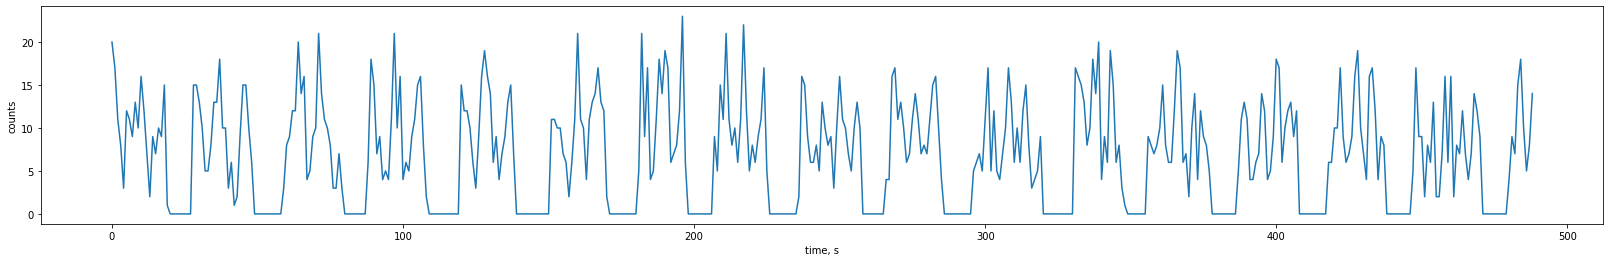

In [17]:
plt.figure(figsize=(28, 4))
#plt.xlim([10000, 12000])
plt.plot(bins_edges[:-1] - data.min(), binned_data)
plt.xlabel('time, s')
plt.ylabel('counts')
plt.show()

In [447]:
# plt.figure(figsize=(28, 4))
# #plt.xlim([10000, 12000])
# plt.bar(bins_edges[:-1] - data.min(), binned_data, dt)
# plt.xlabel('time, s')
# plt.ylabel('counts')
# plt.show()

In [448]:
power = np.abs(rfft(binned_data))**2 / len(data)
n = power.size
freqs = np.arange(n) * df

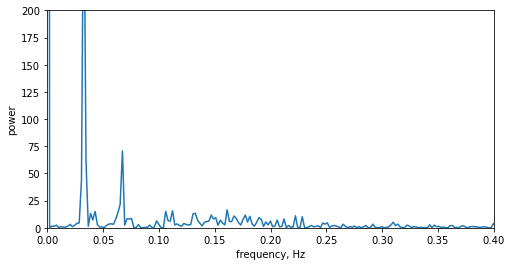

In [449]:
plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.ylim([0, 200])
#plt.xlim([11.18434, 11.18439])
plt.xlim([0.0, 0.4])
#plt.semilogy(freqs, power)
#plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.16g}'))
plt.xlabel('frequency, Hz')
plt.ylabel('power')
plt.show()

In [453]:
#N_events = len(binned_data)   # here data is unbinned time series
Tobs = data[-1]-data[0]

df = 1 / Tobs
M_f = 50
nharm = 1
f_min, f_max = 0, 0.4 
fs = np.arange(f_min, f_max, df / M_f)


In [454]:
df

0.0020395974948088803

In [455]:
fmax/df   #independent trials

245.14640818719593

In [456]:
%time z2 = Znsq_grid(fs, [0], data, nharm=nharm)    

CPU times: user 4.72 s, sys: 89.4 ms, total: 4.81 s
Wall time: 1.06 s


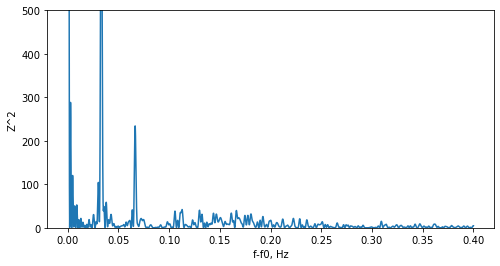

In [457]:
plt.figure(figsize=(8, 4))
plt.ylim([0, 500])
plt.plot(fs , z2)
plt.xlabel('f-f0, Hz')
plt.ylabel('Z^2')
#plt.xlim([-0.0001, +0.0001])
plt.show()

In [458]:
# f, t, Sxx = signal.spectrogram(binned_data, fs=1 * fmax, window=('boxcar'))

# w = np.where((f < 0.5) & (f > 0.05))

# plt.figure(figsize=(16, 2))

# plt.pcolormesh(t, f[w], Sxx[w]+1, shading='gouraud')
# plt.plot([min(t), max(t)],[0.05,0.25], c='y', alpha=0.5)

# plt.ylabel('Frequency [Hz]')
# plt.xlabel('Time [sec]')
# plt.show()

In [459]:
from scipy import signal
from scipy.fft import fftshift
# import matplotlib.pyplot as plt

In [460]:
#signal.spectrogram?

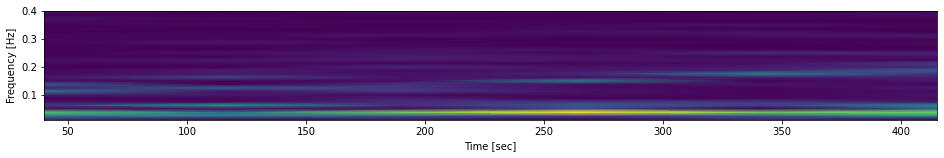

In [470]:
# This is some existing STFT function but its normalization is unclear. So, write STFT yourself or find out how to normalize this one so that the distribution  
# in the absence of any periodic modulation is that of chi^2 with 2 degrees of freedom

f, t, Sxx = signal.spectrogram(binned_data, fs=sr, window=('boxcar'),nperseg=80,noverlap=5)

#w = np.where((f < 0.11) & (f > 0.03))

plt.figure(figsize=(16, 2))

plt.pcolormesh(t, f, Sxx+1, shading='gouraud')
plt.plot( c='y', alpha=0.5)
plt.ylim([0.01, 0.4])
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [397]:


t

array([ 50., 140., 230., 320., 410.])

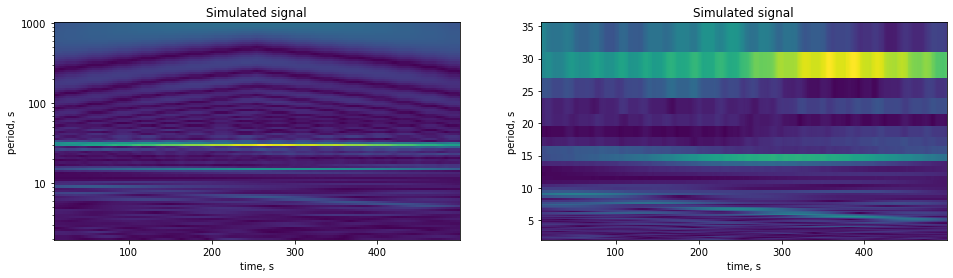

In [495]:
sr=1

fmax = 0.5 * sr
dt = 1 / sr
df=1/(data[-1]-data[0])


ww = 50 # parameter of morlet wavelet

frequ = np.logspace(np.log10(1/1000), np.log10(fmax), 100)
widths = ww*sr / (2*np.pi * frequ)
cwtm = signal.cwt(binned_data, signal.morlet2, widths, w=ww)

plt.figure(figsize=(16, 4))

plt.subplot(121)
plt.pcolormesh(bins_edges[0:-1], 1 / frequ, np.abs(cwtm))
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.16g}'))
plt.title('Simulated signal')
plt.xlabel('time, s')
plt.ylabel('period, s')

frequ = np.linspace(0.03, fmax, 100)
widths = ww*sr / (2*np.pi * frequ)
cwtm = signal.cwt(binned_data, signal.morlet2, widths, w=ww)

plt.subplot(122)
plt.pcolormesh(bins_edges[0:-1], 1 / frequ, np.abs(cwtm))
plt.title('Simulated signal')
plt.xlabel('time, s')
plt.ylabel('period, s')

plt.show()